# Linear Regression for Complete Beginners

## 1. Title and Learning Goals

### What this lesson is about
Linear regression is one of the simplest ways to find a relationship between two things. It helps us answer questions like:
- If study hours go up, how might exam score change?
- If house size goes up, how might price change?

### Learning goals
By the end of this notebook, you will be able to:
- explain linear regression in simple words
- understand words like feature, target, slope, intercept, and residual
- follow a small step-by-step calculation
- build a simple linear regression model in Python
- interpret the model's output and predictions

### How to use this notebook
Move slowly. Run one code cell at a time. After each output, ask yourself:
- What changed?
- What stayed the same?
- What does this tell me about the pattern in the data?

## 2. Simple Prerequisites

You do not need much before starting this lesson.

Helpful background:
- basic Python variables and lists
- how to run notebook cells
- simple arithmetic like addition and division

If some words feel new, that is fine. We will explain them right away in plain English.

## 3. Core Intuition Behind Linear Regression

Linear regression tries to draw the best straight line through data points.

A data point is one example, like one student and their study hours.
A pattern means a repeated relationship, like 'more study hours usually leads to higher scores.'

When the pattern is close to a straight line, linear regression is a useful tool.

### A tiny example to spot the pattern

What you will learn: how to look at a few input-output pairs and notice a simple pattern.
Why it matters: linear regression starts by finding a relationship between an input and an output.
What to focus on: when the input gets bigger, does the output also get bigger in a steady way?

In [1]:
# Toy data: hours studied and exam score
study_hours = [1, 2, 3, 4, 5]
exam_scores = [50, 55, 65, 70, 80]

print('Study hours -> Exam score')
for hours, score in zip(study_hours, exam_scores):
    # Print each pair so the pattern is easy to see
    print(f'{hours} hour(s) -> {score}')

Study hours -> Exam score
1 hour(s) -> 50
2 hour(s) -> 55
3 hour(s) -> 65
4 hour(s) -> 70
5 hour(s) -> 80


### Recap

You just saw a simple pattern: as study hours increased, exam scores also increased. That does not prove a perfect rule, but it suggests a relationship. Linear regression tries to capture that relationship with a straight line.

## 4. Basic Examples

We will now look at a very simple straight-line rule.

If a line follows the rule `y = 2x + 1`, it means:
- when `x` goes up by 1, `y` goes up by 2
- when `x = 0`, the line starts at 1

This helps build intuition before we ask a computer to learn the line from data.

### Using a simple line rule

What you will learn: how a straight-line equation turns inputs into predictions.
Why it matters: linear regression creates a line that behaves like this, except it learns the numbers from data.
What to focus on: notice how the prediction changes in a consistent way each time `x` increases.

In [2]:
# A simple line rule
def simple_line(x):
    # This line says y = 2x + 1
    return 2 * x + 1

for x_value in [0, 1, 2, 3, 4]:
    predicted_y = simple_line(x_value)
    print(f'x = {x_value}, predicted y = {predicted_y}')

x = 0, predicted y = 1
x = 1, predicted y = 3
x = 2, predicted y = 5
x = 3, predicted y = 7
x = 4, predicted y = 9


## 5. Step-by-Step Explanation of How It Works

Linear regression learns a line that is often written as:

`y = mx + b`

Plain-English meaning:
- `x`: the input, also called a feature
- `y`: the output we want to predict, also called a target
- `m`: the slope, which tells us how much `y` changes when `x` changes
- `b`: the intercept, which tells us where the line starts when `x = 0`

Next, we will calculate a line from a tiny dataset step by step.

### Manually finding the slope and intercept

What you will learn: how a best-fit line can be built from simple calculations.
Why it matters: even if a library does the math for you later, understanding the pieces removes the mystery.
What to focus on: watch how we calculate the averages first, then the slope, then the intercept.

In [3]:
import numpy as np

# Tiny dataset
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([50, 55, 65, 70, 80], dtype=float)

# Step 1: find the averages (means)
x_mean = x.mean()
y_mean = y.mean()

print('Average x:', x_mean)
print('Average y:', y_mean)

# Step 2: calculate the slope
numerator = ((x - x_mean) * (y - y_mean)).sum()
denominator = ((x - x_mean) ** 2).sum()
slope = numerator / denominator

# Step 3: calculate the intercept
intercept = y_mean - slope * x_mean

print('Numerator:', numerator)
print('Denominator:', denominator)
print('Slope:', round(slope, 2))
print('Intercept:', round(intercept, 2))

Average x: 3.0
Average y: 64.0
Numerator: 75.0
Denominator: 10.0
Slope: 7.5
Intercept: 41.5


### Recap

You manually built a line from data. The slope tells you how fast the prediction changes. The intercept tells you the starting point. This is the heart of linear regression: use data to choose a line that fits the pattern well.

## 6. Important Related Concepts

Before building a model with a library, let us learn a few important words in plain English:

- feature: the input value we use to predict something
- target: the answer we want to predict
- prediction: the model's guess
- residual: the difference between the real answer and the prediction
- model: the rule learned from the data

These words appear often in machine learning, so it is worth learning them early.

### Looking at predictions and residuals

What you will learn: how to compare the line's prediction with the real value.
Why it matters: a model is useful only if its predictions are close to reality.
What to focus on: a small residual means the prediction was close; a large residual means it missed by more.

In [4]:
# Use the line we calculated earlier
predicted_y = slope * x + intercept
residuals = y - predicted_y

print('x | actual y | predicted y | residual')
for x_value, actual, predicted, residual in zip(x, y, predicted_y, residuals):
    # A residual is actual - predicted
    print(f'{x_value:.0f} | {actual:.1f} | {predicted:.1f} | {residual:.1f}')

x | actual y | predicted y | residual
1 | 50.0 | 49.0 | 1.0
2 | 55.0 | 56.5 | -1.5
3 | 65.0 | 64.0 | 1.0
4 | 70.0 | 71.5 | -1.5
5 | 80.0 | 79.0 | 1.0


### Recap

Predictions come from the line. Residuals measure the gap between the real values and the predictions. Good linear regression models usually have smaller residuals than poor ones.

## 7. Practical Examples

Now we will let a machine learning library learn the line for us.

We will use `scikit-learn`, a very common Python machine learning library.
A library is a ready-made package of useful code.

### Training a real linear regression model

What you will learn: how to fit a linear regression model using scikit-learn.
Why it matters: this is the standard practical workflow you will use in many beginner projects.
What to focus on: notice the input shape, the learned slope, and the learned intercept.

In [5]:
from sklearn.linear_model import LinearRegression

# scikit-learn expects the input in 2D shape: rows and columns
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y_scores = np.array([52, 57, 63, 68, 74, 79])

model = LinearRegression()
model.fit(X, y_scores)

print('Learned slope:', round(model.coef_[0], 2))
print('Learned intercept:', round(model.intercept_, 2))

Learned slope: 5.46
Learned intercept: 46.4


### Making predictions with the trained model

What you will learn: how to ask the model for new predictions.
Why it matters: prediction is the practical reason we build many machine learning models.
What to focus on: the model uses the line it learned to estimate scores for new study hours.

In [6]:
new_hours = np.array([2.5, 5.0, 7.5]).reshape(-1, 1)
predicted_scores = model.predict(new_hours)

print('Predictions for new study hours')
for hours, score in zip(new_hours.flatten(), predicted_scores):
    print(f'{hours} hour(s) -> predicted score {score:.1f}')

Predictions for new study hours
2.5 hour(s) -> predicted score 60.0
5.0 hour(s) -> predicted score 73.7
7.5 hour(s) -> predicted score 87.3


### Interpreting model output

What you will learn: how to compare real values with predicted values and how to read an `R^2` score.
Why it matters: building a model is not enough; you also need to judge whether it fits the data reasonably well.
What to focus on: predictions close to the real values are good, and a higher `R^2` usually means a better fit for this dataset.

In [14]:
training_predictions = model.predict(X)
r2_value = model.score(X, y_scores)

print('Hours | Actual score | Predicted score')
for hours, actual, predicted in zip(X.flatten(), y_scores, training_predictions):
    print(f'{hours:.0f} | {actual:.1f} | {predicted:.1f}')

print('\nR^2 score:', round(r2_value, 3))

Hours | Actual score | Predicted score
1 | 52.0 | 51.9
2 | 57.0 | 57.3
3 | 63.0 | 62.8
4 | 68.0 | 68.2
5 | 74.0 | 73.7
6 | 79.0 | 79.1

R^2 score: 0.999


### Printing common regression loss values

What you will learn: how to print a few common numbers used to measure regression errors.
Why it matters: `R^2` is a score, but losses like MAE, MSE, and RMSE tell you how large the prediction errors are.
What to focus on: smaller loss values usually mean better predictions, and each loss measures error in a slightly different way.

Plain-English meanings:
- MAE: mean absolute error, the average size of the mistakes
- MSE: mean squared error, like MAE but it punishes bigger mistakes more
- RMSE: root mean squared error, the square root of MSE so it goes back to the original units
- `R^2`: a fit score, not a loss; higher is better

### Formulas and how to read the scores

What you will learn: the exact formulas for MSE, MAE, RMSE, and `R^2`, plus how to interpret them.
Why it matters: printing numbers is not enough; you need to know what each number says about model quality.
What to focus on: for MAE, MSE, and RMSE lower is better, while for `R^2` higher is better.

Let:
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $n$ = number of data points
- $\bar{y}$ = average of the actual values

#### 1. MAE: Mean Absolute Error

Formula:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

Plain-English meaning:
- Find the error for each point
- Ignore whether it is positive or negative by taking the absolute value
- Average all those error sizes

What analysis we can make from MAE:
- It tells us the average size of the mistakes
- It is easy to explain because it stays in the original unit of the target
- If exam scores are the target, an MAE of 2 means the model is off by about 2 marks on average

Better direction:
- Lower is better
- `0` is perfect

#### 2. MSE: Mean Squared Error

Formula:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Plain-English meaning:
- Find each error
- Square it
- Average the squared errors

Why square the errors:
- Big mistakes become much larger after squaring
- So MSE punishes large errors more strongly than MAE

What analysis we can make from MSE:
- Useful when large mistakes are especially bad
- Sensitive to outliers, which means a few very bad predictions can increase it a lot
- Good for optimization in many machine learning algorithms

Better direction:
- Lower is better
- `0` is perfect

#### 3. RMSE: Root Mean Squared Error

Formula:

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Plain-English meaning:
- Start with MSE
- Then take the square root

Why this helps:
- MSE is in squared units, which can feel unnatural
- RMSE brings the value back to the original unit of the target

What analysis we can make from RMSE:
- Like MSE, it cares a lot about big mistakes
- Like MAE, it is easier to interpret because it is back in the original units
- If RMSE is much larger than MAE, it can hint that some errors are much bigger than others

Better direction:
- Lower is better
- `0` is perfect

#### 4. `R^2`: Coefficient of Determination

Formula:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Plain-English meaning:
- The top part measures model error
- The bottom part measures how much the actual values vary around their average
- `R^2` asks: is the model better than just predicting the average every time?

What analysis we can make from `R^2`:
- `R^2 = 1` means perfect predictions
- `R^2 = 0` means the model is no better than predicting the average
- `R^2 < 0` means the model is worse than just predicting the average
- A higher `R^2` usually means the model explains more of the pattern in the data

Important caution:
- A high `R^2` does not always mean the model is truly good in every situation
- It should be read together with MAE, MSE, or RMSE
- `R^2` can look strong even when some individual prediction errors still matter

Better direction:
- Higher is better
- `1` is perfect

#### Quick comparison

- MAE: average mistake size, lower is better
- MSE: punishes large mistakes more, lower is better
- RMSE: like MSE but back in original units, lower is better
- `R^2`: tells how well the model explains the data pattern compared with predicting the average, higher is better

For this notebook's example:
- Small MAE, MSE, and RMSE mean the predictions are close to the actual scores
- `R^2` close to `1` means the fitted line matches the pattern very well

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_scores, training_predictions)
mse = mean_squared_error(y_scores, training_predictions)
rmse = np.sqrt(mse)
r2_value_from_function = r2_score(y_scores, training_predictions)

print('Regression evaluation values')
print('MAE :', round(mae, 3))
print('MSE :', round(mse, 3))
print('RMSE:', round(rmse, 3))
print('R^2 :', round(r2_value_from_function, 3))

Regression evaluation values
MAE : 0.229
MSE : 0.057
RMSE: 0.239
R^2 : 0.999


### Visualizing the best-fit line

What you will learn: how to see the data points and the learned line on one chart.
Why it matters: plots make the idea of 'best-fit line' much easier to understand.
What to focus on: the dots are real data points, and the line shows the model's predicted trend.

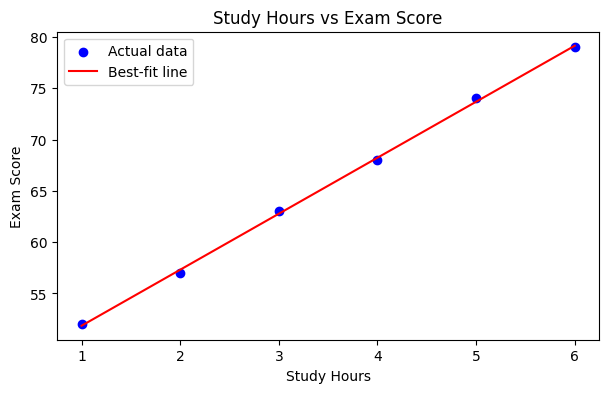

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.scatter(X, y_scores, color='blue', label='Actual data')
plt.plot(X, training_predictions, color='red', label='Best-fit line')
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

### Recap

You have now seen the full beginner workflow: prepare a small dataset, fit a linear regression model, make predictions, check the output, and visualize the line. This is a solid first machine learning example.

## 8. Common Mistakes

Beginners often run into these problems:

- expecting a curved pattern to fit well with a straight line
- mixing up feature (input) and target (output)
- forgetting to reshape the input for scikit-learn
- trusting the prediction without checking whether it matches the data well
- thinking correlation always means causation

Causation means one thing truly causes another. Linear regression can show a relationship, but not always a true cause.

## 9. Mini Exercises and Reflection Questions

Try these after finishing the lesson:

1. If a line has a positive slope, what usually happens to the prediction when the input increases?
2. In your own words, what is the difference between a prediction and a residual?
3. Change one value in the training data and rerun the model. What changes?
4. Replace the study-hours example with your own example, such as temperature and ice cream sales.
5. Look at the plot. Do the points stay close to the line or far from it? What does that suggest?

## 10. Final Summary and Key Takeaways

Here are the big ideas to remember:

- linear regression finds a straight-line relationship between an input and an output
- the line is often written as `y = mx + b`
- slope tells you how much the prediction changes
- intercept tells you where the line starts when `x = 0`
- residuals show the gap between real values and predictions
- scikit-learn can fit the line for you very quickly
- you should always interpret the output instead of only printing numbers

If this topic feels much clearer now, that is the goal. You do not need to memorize everything today. The important part is understanding the story of the method: data -> line -> prediction -> interpretation.